In [1]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

# quick anecdotes about how many stims in old datasetse

In [ ]:
session_path = '../data/co/co12/co12_02132024'
session = MPOptoClass(session_path)

co12 handfix lol
love


In [74]:
nlags = 20
binsize=5
pre = nlags * binsize
post=50
num_PCs=20

laser_bounds = adjustBounds(session.laser['laser_bounds'], pre, post)
ctrl_bounds = adjustBounds(session.laser['ctrl_bounds'], pre, post)

(X, _), X_PCs = session.format_nlags_PCA(bounds=laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y) = session.transformat_smooth(X_PCs, bounds=laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y=Y[:,num_PCs:]

(X_lctrl, _) = session.transformat(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_lctrl) = session.transformat_smooth(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_lctrl=Y_lctrl[:,num_PCs:]

In [75]:
rng = np.random.default_rng(seed=1)
total_samples = X.shape[0]
percents = np.linspace(.1,1,num=15)
h_list=[]
r2_list=[]
ctrl_r2_list=[]
for percent in percents: 
    num_samples = int(percent*total_samples)
    mask = rng.choice(total_samples, size=num_samples, replace=False)
    X_mask = X[mask, :]
    Y_mask = Y[mask, :]
    p, phat, h = wiener_kfolds(X_mask, Y_mask, c=(1,5), k=10)
    r2_list.append(weighted_r2(p, phat))
    h_list.append(h)
    print(r2_list[-1])
    ctrl_phat = test_wiener_filter(X_lctrl, h)
    ctrl_r2_list.append(weighted_r2(Y_lctrl, ctrl_phat))

10it [00:01,  6.24it/s]


0.022136219390729777


10it [00:01,  6.02it/s]


0.07290311850317421


10it [00:01,  5.78it/s]


...

0.15528835027862403


10it [00:02,  4.01it/s]


0.1636065234290741


10it [00:02,  3.93it/s]

0.16833157408338054


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


NameError: name 'percents' is not defined

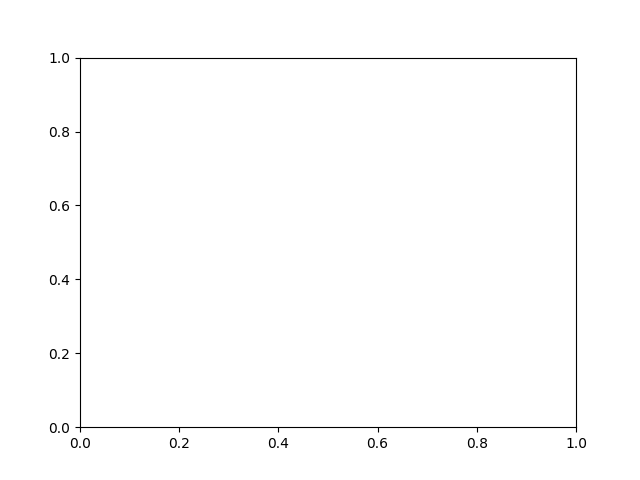

In [17]:
fig, ax = plt.subplots()
num_lasers = []
for percent in percents:
    temp = percent * total_samples
    num_lasers.append(int(temp//15))
ax.plot(num_lasers, r2_list, label='xval on lasers only')
#ax.plot(num_lasers, ctrl_r2_list, c='gray', label='held out ctrls')
ax.set_ylabel('10fold-xval r2')
ax.set_xlabel('num_lasers')
ax.set_title(f'session:{session.name}')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'session:co12_02132024')

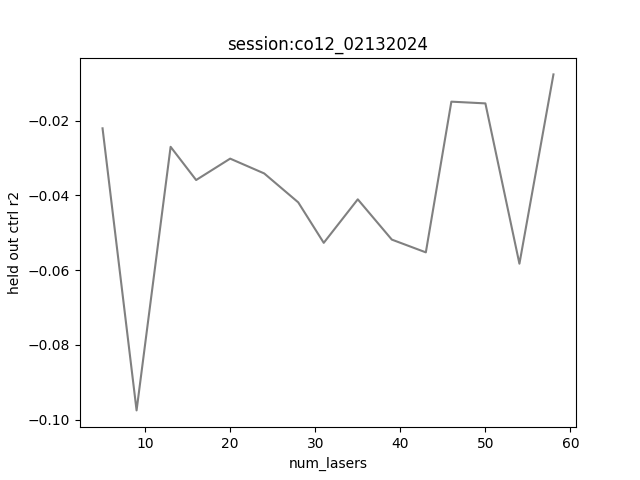

In [77]:
fig, ax = plt.subplots()
ax.plot(num_lasers, ctrl_r2_list, c='gray', label='held out ctrls')
ax.set_ylabel('held out ctrl r2')
ax.set_xlabel('num_lasers')
ax.set_title(f'session:{session.name}')

In [78]:
dist_list = []
for h in h_list:
    dist_list.append(numpy.linalg.norm(h - h_list[-1]))

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'session:co12_02132024')

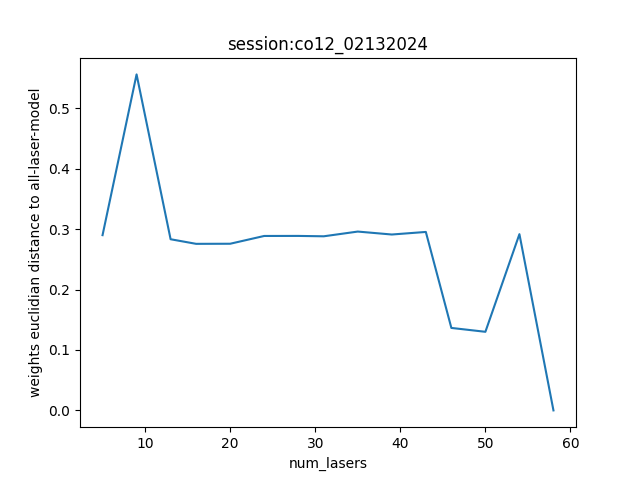

In [79]:
fig, ax = plt.subplots()
ax.plot(num_lasers, dist_list)
ax.set_ylabel('weights euclidian distance to all-laser-model')
ax.set_xlabel('num_lasers')
ax.set_title(f'session:{session.name}')

# looking at to3!

In [2]:
session_path = '../data/to/to3/to3_06052024'
session = MPOptoClass(session_path)

love


# train on everything, predicting climbing/stims of each power

In [3]:
hist, bins = np.histogram(session.laser['laser_powers'], bins=5)
rough_powers = np.digitize(session.laser['laser_powers'], bins)

In [5]:
nlags = 20
binsize=5
pre = nlags * binsize
post=50
num_PCs=20

temp = session.laser['ctrl_bounds']
temp_mask = goodLasers(temp, np.squeeze(session.climbing_logical))
temp = temp[temp_mask,:]
ctrl_bounds = adjustBounds(temp, pre, post)

temp = session.laser['laser_bounds']
temp_mask = goodLasers(temp, np.squeeze(session.climbing_logical))
temp = temp[temp_mask,:]
all_lasers = adjustBounds(temp, pre, post)
train_lasers, test_lasers = train_test_split(all_lasers, test_size=.2, random_state=2)

omit_test_lasers = adjustBounds(test_lasers, 0, 150)
omit_all_lasers = adjustBounds(all_lasers, 0, 150)

all_bounds = omitBoundInBounds(session.climbing_bounds, omit_test_lasers)
all_bounds = omitBoundInBounds(all_bounds, ctrl_bounds)

climb_bounds = omitBoundInBounds(session.climbing_bounds, omit_all_lasers)
climb_bounds = omitBoundInBounds(climb_bounds, ctrl_bounds)

(X_all, _), X_all_PCs = session.format_nlags_PCA(bounds=all_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_all) = session.transformat_smooth(X_all_PCs, bounds=all_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_all=Y_all[:,:num_PCs]

(X_climb, _), X_climb_PCs = session.format_nlags_PCA(bounds=climb_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_climb) = session.transformat_smooth(X_climb_PCs, bounds=climb_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_climb=Y_climb[:,:num_PCs]

(X_test, _) = session.transformat(X_all_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_test) = session.transformat_smooth(X_all_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_test=Y_test[:,:num_PCs]

(X_ctrl, _) = session.transformat(X_all_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_ctrl) = session.transformat_smooth(X_all_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_ctrl=Y_ctrl[:,:num_PCs]



bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too sma

In [6]:
h_all = train_wiener_filter(X_all, Y_all, c=(1,5))
h_climb = train_wiener_filter(X_climb, Y_climb, c=(1,5))

In [7]:
phat_all_test = test_wiener_filter(X_test, h_all)
phat_all_ctrl = test_wiener_filter(X_ctrl, h_all)
phat_climb_test = test_wiener_filter(X_test, h_climb)
phat_climb_ctrl = test_wiener_filter(X_ctrl, h_climb)

all_test_score = weighted_r2(Y_test, phat_all_test)
all_ctrl_score = weighted_r2(Y_ctrl, phat_all_ctrl)

climb_test_score = weighted_r2(Y_test, phat_climb_test)
climb_ctrl_score = weighted_r2(Y_ctrl, phat_climb_ctrl)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


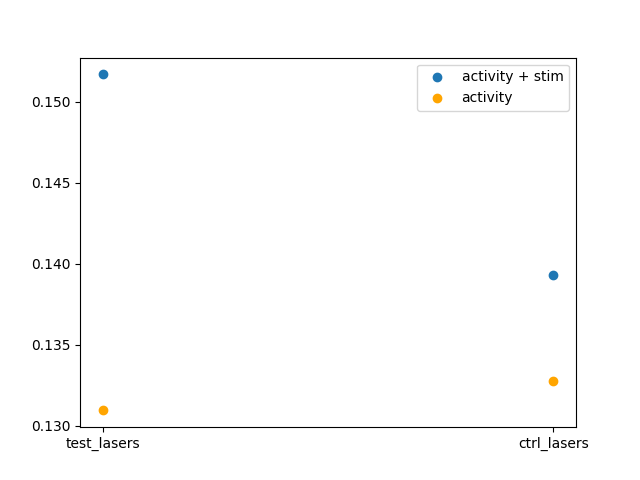

In [8]:
fig, ax = plt.subplots()
ax.scatter(['test_lasers', 'ctrl_lasers'], [all_test_score, all_ctrl_score], label='activity + stim')
ax.scatter(['test_lasers', 'ctrl_lasers'], [climb_test_score, climb_ctrl_score], c='orange', label='activity')
ax.legend()

In [9]:
CFA_all_drive, THAL_all_drive = session.relative_input(h_all, X_ctrl, nlags, num_PCs)
CFA_climb_drive, THAL_climb_drive = session.relative_input(h_climb, X_ctrl, nlags, num_PCs)

all_ratio = np.log10(CFA_all_drive/THAL_all_drive)
climb_ratio = np.log10(CFA_climb_drive/THAL_climb_drive)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0, 0.5, 'log(cfa/thal)')

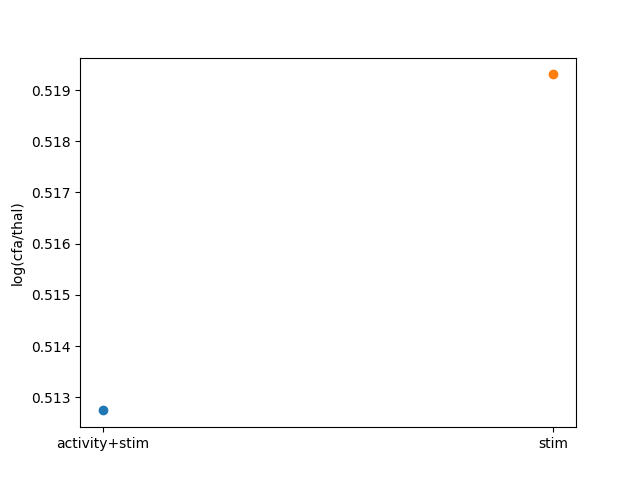

In [10]:
fig, ax = plt.subplots()
ax.scatter('activity+stim', all_ratio)
ax.scatter('stim', climb_ratio)
ax.set_ylabel('log(cfa/thal)')

# train on climbing, predict each laser power

In [11]:
hist, bins = np.histogram(session.laser['laser_powers'], bins=5)
rough_powers = np.digitize(session.laser['laser_powers'], bins)

In [12]:
nlags = 20
binsize=5
pre = nlags * binsize
post=50
num_PCs=20

all_lasers = session.laser['laser_bounds']
all_lasers_adjust = adjustBounds(all_lasers, pre, post)
climb_lasers_mask = goodLasers(all_lasers_adjust, np.squeeze(session.climbing_logical))
climb_lasers = all_lasers_adjust[climb_lasers_mask,:]

climbing_bounds = omitBoundInBounds(session.climbing_bounds, climb_lasers)

(X, _), X_PCs = session.format_nlags_PCA(bounds=climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y) = session.transformat_smooth(X_PCs, bounds=climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y=Y[:,:num_PCs]

bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too sma

In [13]:
h_climb = train_wiener_filter(X, Y, c=(1,5))

ctrl_bounds = adjustBounds(session.laser['ctrl_bounds'], pre, post)
ctrl_bounds_mask = goodLasers(ctrl_bounds, np.squeeze(session.climbing_logical))
ctrl_bounds = ctrl_bounds[ctrl_bounds_mask,:]

(X_ctrl, _) = session.transformat(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_ctrl) = session.transformat_smooth(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_ctrl=Y_ctrl[:,:num_PCs]

phat_ctrl = test_wiener_filter(X_ctrl, h_climb)

ctrl_score = weighted_r2(Y_ctrl, phat_ctrl)
print(weighted_r2(Y_ctrl, phat_ctrl))

0.15622758697840383


In [14]:
r2_list = []
for this_power in np.arange(1,6):
    this_power_lasers = all_lasers_adjust[rough_powers==this_power,:]
    climb_mask = goodLasers(this_power_lasers, np.squeeze(session.climbing_logical))
    this_power_lasers = this_power_lasers[climb_mask,:]
    
    print(f'num_lasers:{len(this_power_lasers)}')
    
    (X_test, _) = session.transformat(X_PCs, bounds=this_power_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    (_, Y_test) = session.transformat_smooth(X_PCs, bounds=this_power_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
    Y_test=Y_test[:,num_PCs:]
    
    phat = test_wiener_filter(X_test, h_climb)
    r2_score = weighted_r2(Y_test, phat)
    print(r2_score)
    r2_list.append(r2_score)
    

num_lasers:43
-0.10929073368504189
num_lasers:45
-0.1591126079444162
num_lasers:36
-0.12153496193634011
num_lasers:39
-0.1441781852287528
num_lasers:29
-0.31431598217094925


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'trained on climbing, predicting lasers')

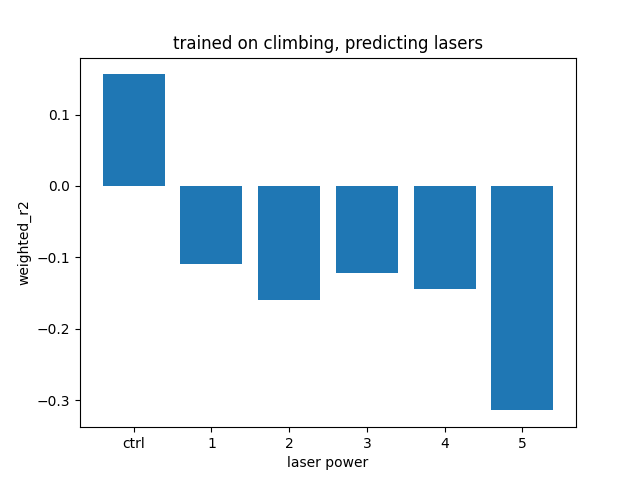

In [15]:
fig, ax = plt.subplots()
labels=['ctrl', '1', '2', '3', '4', '5']
ax.bar(labels, [ctrl_score] + r2_list)
ax.set_ylabel('weighted_r2')
ax.set_xlabel('laser power')
ax.set_title('trained on climbing, predicting lasers')

In [16]:
nlags = 20
binsize=5
pre = nlags * binsize
post=50
num_PCs=20

this_power=1

all_lasers = session.laser['laser_bounds']
test_lasers = all_lasers[raw_powers==this_power]
climb_lasers_mask = goodLasers(all_lasers, np.squeeze(session.climbing_logical))
climb_lasers = all_lasers[climb_lasers_mask,:]

laser_bounds = adjustBounds(climb_lasers, pre, post)
ctrl_bounds = adjustBounds(session.laser['ctrl_bounds'], pre, post)

(X, _), X_PCs = session.format_nlags_PCA(bounds=laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y) = session.transformat_smooth(X_PCs, bounds=laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y=Y[:,:num_PCs]

(X_lctrl, _) = session.transformat(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_lctrl) = session.transformat_smooth(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_lctrl=Y_lctrl[:,:num_PCs]

NameError: name 'raw_powers' is not defined

In [ ]:
rng = np.random.default_rng(seed=1)
total_samples = X.shape[0]
percents = np.linspace(.1,1,num=15)
h_list=[]
r2_list=[]
ctrl_r2_list=[]
for percent in percents: 
    num_samples = int(percent*total_samples)
    mask = rng.choice(total_samples, size=num_samples, replace=False)
    X_mask = X[mask, :]
    Y_mask = Y[mask, :]
    p, phat, h = wiener_kfolds(X_mask, Y_mask, c=(1,5), k=10)
    r2_list.append(weighted_r2(p, phat))
    h_list.append(h)
    print(r2_list[-1])
    ctrl_phat = test_wiener_filter(X_lctrl, h)
    ctrl_r2_list.append(weighted_r2(Y_lctrl, ctrl_phat))

In [ ]:
fig, ax = plt.subplots()
num_lasers = []
for percent in percents:
    temp = percent * total_samples
    num_lasers.append(int(temp//15))
ax.plot(num_lasers, r2_list, label='xval on lasers only')
#ax.plot(num_lasers, ctrl_r2_list, c='gray', label='held out ctrls')
ax.set_ylabel('10fold-xval r2')
ax.set_xlabel('num_lasers')
ax.set_title(f'session:{session.name}')

In [ ]:
fig, ax = plt.subplots()
ax.plot(num_lasers, ctrl_r2_list, c='gray', label='held out ctrls')
ax.set_ylabel('held out ctrl r2')
ax.set_xlabel('num_lasers')
ax.set_title(f'session:{session.name}')

In [ ]:
fig, ax = plt.subplots()
ax.plot(num_lasers, dist_list)
ax.set_ylabel('weights euclidian distance to all-laser-model')
ax.set_xlabel('num_lasers')
ax.set_title(f'session:{session.name}')

In [167]:
nlags = 20
binsize=5
pre = nlags * binsize
post=50
num_PCs=20

climb_nolaser = omitBoundInBounds(session.climbing_bounds, laser_bounds)
climb_nolaser = omitBoundInBounds(climb_nolaser, ctrl_bounds)

(X, _), X_PCs = session.format_nlags_PCA(bounds=climb_nolaser, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y) = session.transformat_smooth(X_PCs, bounds=climb_nolaser, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y=Y[:,num_PCs:]

(X_lctrl, _) = session.transformat(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_lctrl) = session.transformat_smooth(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_lctrl=Y_lctrl[:,num_PCs:]

bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
bounds too sma

In [168]:
X.shape

(70446, 800)

In [169]:
p, phat, h = wiener_kfolds(X, Y, c=(1,5), k=4)
print(weighted_r2(p, phat))

4it [00:31,  7.80s/it]

0.20344474252869119


# laser powers predicting each other

In [3]:
session_path = '../data/to/to3/to3_06042024'
session = MPOptoClass(session_path)

love


In [4]:
hist, bins = np.histogram(session.laser['laser_powers'], bins=5)
rough_powers = np.digitize(session.laser['laser_powers'], bins)

In [10]:
nlags = 20
binsize=5
pre = nlags * binsize
post=50
num_PCs=20

num_powers = np.arange(1,6)
output =[]

for power in num_powers:
    
        
    temp = session.laser['laser_bounds']
    temp = temp[rough_powers==power,:]
    temp_mask = goodLasers(temp, np.squeeze(session.climbing_logical))
    test_lasers, only_lasers = train_test_split(temp[temp_mask,:], test_size=.8, random_state=2)
    
    only_laser_bounds = adjustBounds(only_lasers, pre, post)
    test_laser_bounds = adjustBounds(test_lasers, pre, post)
    
    temp = session.laser['laser_bounds']
    temp = temp[rough_powers!=power,:]
    temp_mask = goodLasers(temp, np.squeeze(session.climbing_logical))
    subset_lasers = temp[temp_mask,:]
    subset_laser_bounds = adjustBounds(subset_lasers, pre, post)

    
    temp = session.laser['laser_bounds']
    all_lasers_mask = goodLasers(temp, np.squeeze(session.climbing_logical))
    all_lasers = temp[all_lasers_mask,:]    
    all_laser_bounds = adjustBounds(all_lasers, pre, post)
    all_laser_bounds = omitBoundInBounds(all_laser_bounds, test_laser_bounds)
    
    temp = session.climbing_bounds
    all_climb_bounds = omitBoundInBounds(temp, test_laser_bounds)

    
    print(f'climb_segments: {len(all_climb_bounds)}')
    print(f'num_all_lasers: {len(all_laser_bounds)}')
    print(f'num_sub_lasers: {len(subset_laser_bounds)}')
    print(f'num_only_lasers: {len(only_laser_bounds)}')
    print(f'num_test_lasers: {len(test_laser_bounds)}')
    
    (X, _), climb_PCs = session.format_nlags_PCA(bounds=all_climb_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    (_, Y) = session.transformat_smooth(climb_PCs, bounds=all_climb_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
    Y=Y[:,num_PCs:]

    (X_all, _), X_PCs = session.format_nlags_PCA(bounds=all_laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    (_, Y_all) = session.transformat_smooth(X_PCs, bounds=all_laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
    Y_all=Y_all[:,num_PCs:]
    
    (X_sub, _), X_PCs = session.format_nlags_PCA(bounds=subset_laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    (_, Y_sub) = session.transformat_smooth(X_PCs, bounds=subset_laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
    Y_sub=Y_sub[:,num_PCs:]
    
        
    (X_only, _), X_PCs = session.format_nlags_PCA(bounds=only_laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    (_, Y_only) = session.transformat_smooth(X_PCs, bounds=only_laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
    Y_only=Y_only[:,num_PCs:]
    
    (X_test, _) = session.transformat(climb_PCs, bounds=test_laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    (_, Y_test) = session.transformat_smooth(climb_PCs, bounds=test_laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
    Y_test=Y_test[:,num_PCs:]
    
    h_climb = train_wiener_filter(X, Y, c=(1,5))
    h_all = train_wiener_filter(X_all, Y_all, c=(1,5))
    h_sub = train_wiener_filter(X_sub, Y_sub, c=(1,5))
    h_only = train_wiener_filter(X_only, Y_only, c=(1,5))
    
    phat_climb = test_wiener_filter(X_test, h_climb)
    phat_all = test_wiener_filter(X_test, h_all)
    phat_sub = test_wiener_filter(X_test, h_sub)
    phat_only = test_wiener_filter(X_test, h_only)
    
    climb_r2 = weighted_r2(Y_test, phat_climb)
    all_r2 = weighted_r2(Y_test, phat_all)
    sub_r2 = weighted_r2(Y_test, phat_sub)
    only_r2 = weighted_r2(Y_test, phat_only)
    
    output.append((climb_r2, all_r2, sub_r2, only_r2))
    
    print(f'climb:{climb_r2}\n')
    print(f'all:{all_r2}')
    print(f'sub:{sub_r2}')
    print(f'only:{only_r2}\n')

    



climb_segments: 168
num_all_lasers: 302
num_sub_lasers: 247
num_only_lasers: 55
num_test_lasers: 13
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
climb:0.18586037821562348

all:0.06259949851230637
sub:-0.020346629127645646
only:-0.014558528607816111

climb_segments: 168
num_all_lasers: 302
num_sub_lasers: 250
num_only_lasers: 52
num_test_lasers: 13
bounds too small for history
bounds too small for history
bounds too small for history
bounds too small for history
climb:0.20389052076460285

all:0.06556819618861608
sub:0.04395955935341605
only:0.07857019362954472

climb_segments: 164
num_all_lasers: 305
num_sub_lasers: 263
num_only_lasers: 42
num_test_lasers: 10
climb:0.029112312327309323

all:-0.017114221082010453
sub:-0.057661057798335094
only:-0.06403474990513996

climb_segments: 166
num_all_lasers: 304
num_sub_lasers: 257
num_only_lasers: 47
num_test_lasers: 11
climb:0.026479857047112323

all:-0.08927781537110999
su

In [12]:
r2_dict = {}

r2_dict['climb+all lasers'] = []
r2_dict['all lasers'] = []
r2_dict['all lasers except power'] = []
r2_dict['just lasers of this power'] = []
for o in output:
    r2_dict['climb+all lasers'].append(o[0])
    r2_dict['all lasers'].append(o[1])
    r2_dict['all lasers except power'].append(o[2])
    r2_dict['just lasers of this power'].append(o[3])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


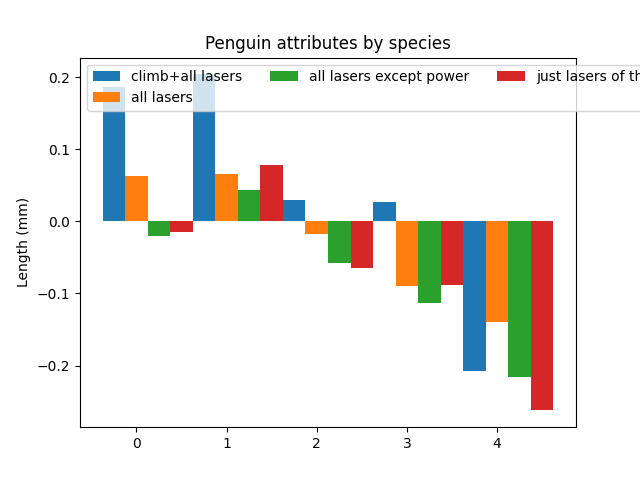

In [20]:

x = np.arange(5)  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots()

for attribute, measurement in r2_dict.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Length (mm)')
ax.set_title('Penguin attributes by species')
ax.set_xticks(x + width, x)
ax.legend(loc='upper left', ncols=3)
#ax.set_ylim(0, 250)

plt.show()

In [29]:
rng = np.random.default_rng(seed=1)
total_samples = X.shape[0]
percents = np.linspace(.1,1,num=15)
h_list=[]
r2_list=[]
ctrl_r2_list=[]
for percent in percents: 
    num_samples = int(percent*total_samples)
    mask = rng.choice(total_samples, size=num_samples, replace=False)
    X_mask = X[mask, :]
    Y_mask = Y[mask, :]
    p, phat, h = wiener_kfolds(X_mask, Y_mask, c=(1,5), k=10)
    r2_list.append(weighted_r2(p, phat))
    h_list.append(h)
    print(r2_list[-1])
    ctrl_phat = test_wiener_filter(X_lctrl, h)
    ctrl_r2_list.append(weighted_r2(Y_lctrl, ctrl_phat))

10it [00:10,  1.04s/it]

0.2064779679261893


NameError: name 'X_lctrl' is not defined